Total images: 433


(-0.5, 499.5, 267.5, -0.5)

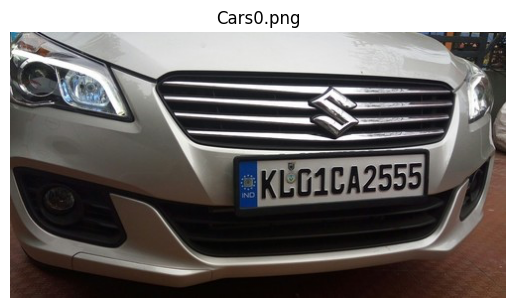

In [4]:
import os
import cv2
import matplotlib.pyplot as plt

IMG_PATH = "../data/raw/images"

images = os.listdir(IMG_PATH)

print("Total images:", len(images))

# show sample image
img_path = os.path.join(IMG_PATH, images[0])
img = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(images[0])
plt.axis("off")

In [5]:
import xml.etree.ElementTree as ET

ANN_PATH = "../data/raw/annotations"

xml_file = images[0].replace(".png", ".xml")
xml_path = os.path.join(ANN_PATH, xml_file)

tree = ET.parse(xml_path)
root = tree.getroot()

for obj in root.findall("object"):
    bbox = obj.find("bndbox")
    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)

    print("Bounding Box:", xmin, ymin, xmax, ymax)

Bounding Box: 226 125 419 173


(-0.5, 499.5, 267.5, -0.5)

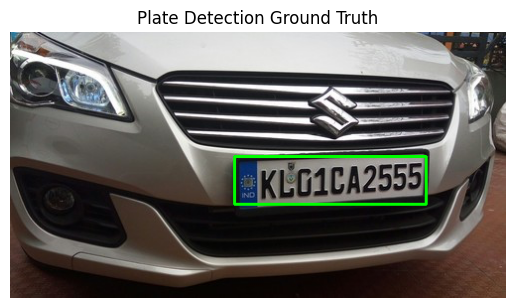

In [6]:
img_box = img.copy()
cv2.rectangle(img_box, (xmin,ymin), (xmax,ymax), (0,255,0), 2)

plt.imshow(img_box)
plt.title("Plate Detection Ground Truth")
plt.axis("off")